# Thinkpad-2 dataset — deep dive

**Scope**
- `datasets/thinkpad-2` only (class folders at dataset root; **36 classes × 20 samples**)
- Different keyboard from original `thinkpad`
- Integrity, duration, waveform scalars, CQT-derived spectral / label metrics
- Outliers and within-dataset near-duplicates

**Out of scope**
- Onset / multi-onset analysis
- Model training (CNN eval can use extracted features separately)

**Artifacts**
- `datasets/thinkpad-2-dataset-info.pkl` — duration inventory
- `features/thinkpad-2.npz` — cached CQT `(N, 216, 188)`
- Metrics cache: `datasets/thinkpad-2-sample-metrics.pkl`


In [1]:
from os import path, listdir
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from tqdm.notebook import tqdm
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# --- per-dataset config (this notebook is under notebooks/thinkpad/) ---
DATASET = "thinkpad-2"
# feature cache filename for this dataset
FEATURES_NAME = "thinkpad-2.npz"

DATASET_DIR = path.normpath(f"../../datasets/{DATASET}")
SOURCE_PATH = DATASET_DIR
TRAIN_DIR = DATASET_DIR
INVENTORY_PATH = path.normpath(f"../../datasets/{DATASET}-dataset-info.pkl")
FEATURES_PATH = path.normpath(f"../../features/{FEATURES_NAME}")
METRICS_PATH = path.normpath(f"../../datasets/{DATASET}-sample-metrics.pkl")

AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_BINS_PER_OCTAVE = 36
CQT_OCTAVES = 6
CQT_FMIN = librosa.note_to_hz("C1")
CQT_FEATURE_FRAMES = round(2.0 * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)  # 188
CQT_FLOOR_DB = -80.0

BOXPROPS = dict(color="#01696f", linewidth=1.4)
WHISKERPROPS = dict(color="#01696f", linewidth=1.2, linestyle="--")
MEDIANPROPS = dict(color="#da7101", linewidth=2)
FLIERPROPS = dict(
    marker="o", markerfacecolor="#a12c7b", markersize=4, linestyle="none", alpha=0.6
)

display(pd.DataFrame([
    {"key": "dataset", "value": DATASET},
    {"key": "dataset_dir", "value": DATASET_DIR},
    {"key": "features", "value": FEATURES_PATH},
    {"key": "metrics_cache", "value": METRICS_PATH},
    {"key": "cqt_feature_frames (2s)", "value": CQT_FEATURE_FRAMES},
    {"key": "audio_sample_rate", "value": AUDIO_SAMPLE_RATE},
]))


,key,value
0,dataset,thinkpad-2
1,dataset_dir,../../datasets/thinkpad-2
2,features,../../features/thinkpad-2.npz
3,metrics_cache,../../datasets/thinkpad-2-sample-metrics.pkl
4,cqt_feature_frames (2s),188
5,audio_sample_rate,48000


## 1. Inventory & duration

Load the existing duration inventory if present; otherwise scan training audio once.
Parse class names into root / quality / octave and keep **training only**.


In [2]:
def scan_dataset_inventory(source_path: str) -> pd.DataFrame:
    """Walk dataset/{class}/* audio files (sorted) and record durations."""
    records = []
    dataset_type = path.basename(source_path)
    for class_name in tqdm(sorted(listdir(source_path)), desc=f"  {dataset_type}"):
        class_path = path.join(source_path, class_name)
        if not path.isdir(class_path):
            continue
        for audio_file in sorted(listdir(class_path)):
            audio_path = path.join(class_path, audio_file)
            if not path.isfile(audio_path):
                continue
            # skip non-audio keepers
            if audio_file.startswith(".") or not audio_file.lower().endswith(
                (".ogg", ".wav", ".flac", ".mp3")
            ):
                continue
            try:
                duration = librosa.get_duration(path=audio_path)
                records.append(
                    {
                        "dataset_type": dataset_type,
                        "class_name": class_name,
                        "filename": audio_file,
                        "duration_s": duration,
                    }
                )
            except Exception as e:
                display(Markdown(f"**WARN** Could not read `{audio_path}`: {e}"))
    return pd.DataFrame(records)


def list_audio_keys(source_path: str) -> set:
    """Set of class/filename keys currently on disk (sorted walk, audio only)."""
    keys = set()
    for class_name in sorted(listdir(source_path)):
        class_path = path.join(source_path, class_name)
        if not path.isdir(class_path):
            continue
        for audio_file in sorted(listdir(class_path)):
            if audio_file.startswith("."):
                continue
            if not audio_file.lower().endswith((".ogg", ".wav", ".flac", ".mp3")):
                continue
            if path.isfile(path.join(class_path, audio_file)):
                keys.add(f"{class_name}/{audio_file}")
    return keys


def inventory_is_current(inventory: pd.DataFrame, source_path: str, dataset_name: str) -> bool:
    """True only if inventory is a clean, single-dataset mirror of disk."""
    if inventory is None or len(inventory) == 0:
        return False
    required = {"dataset_type", "class_name", "filename", "duration_s"}
    if not required.issubset(set(inventory.columns)):
        return False
    # Must not mix other dataset_types (e.g. legacy evaluation rows)
    types = set(inventory["dataset_type"].astype(str).unique())
    if types != {dataset_name}:
        return False
    disk_keys = list_audio_keys(source_path)
    inv_keys = set(
        inventory["class_name"].astype(str) + "/" + inventory["filename"].astype(str)
    )
    return disk_keys == inv_keys


def parse_class_name(name: str) -> pd.Series:
    m = re.match(r"^([A-G]#?)_(major|minor|diminished)_(\d+)$", name)
    if not m:
        return pd.Series({"root": None, "quality": None, "octave": None})
    return pd.Series(
        {"root": m.group(1), "quality": m.group(2), "octave": int(m.group(3))}
    )


def file_index(filename: str):
    m = re.search(r"-(\d+)\.(ogg|wav)$", filename, re.I)
    return int(m.group(1)) if m else np.nan


inventory = None
if path.exists(INVENTORY_PATH):
    try:
        inventory = pd.read_pickle(INVENTORY_PATH)
    except Exception as e:
        display(Markdown(
            f"**WARN** Could not load inventory `{INVENTORY_PATH}` "
            f"({type(e).__name__}: {e}). Rescanning."
        ))
        inventory = None

if inventory is not None and inventory_is_current(inventory, DATASET_DIR, DATASET):
    display(Markdown(
        f"Loaded current inventory from `{INVENTORY_PATH}` (**{len(inventory)}** rows)"
    ))
else:
    if inventory is not None:
        display(Markdown(
            f"**WARN** Inventory at `{INVENTORY_PATH}` is stale or non-standard "
            f"(rows={len(inventory)}, types={sorted(inventory['dataset_type'].astype(str).unique()) if 'dataset_type' in inventory.columns else 'n/a'}). "
            f"Rescanning `{DATASET_DIR}` for reproducibility."
        ))
    inventory = scan_dataset_inventory(DATASET_DIR)
    inventory.to_pickle(INVENTORY_PATH)
    display(Markdown(
        f"Scanned and saved inventory to `{INVENTORY_PATH}` (**{len(inventory)}** rows)"
    ))

# Single-dataset inventory after validation: all rows belong to DATASET
df = inventory.reset_index(drop=True)
meta = df["class_name"].apply(parse_class_name)
df = pd.concat([df, meta], axis=1)
df["file_idx"] = df["filename"].map(file_index)
df["audio_path"] = [
    path.join(DATASET_DIR, c, f) for c, f in zip(df["class_name"], df["filename"])
]

summary = pd.DataFrame([
    {"metric": "rows", "value": len(df)},
    {"metric": "n_classes", "value": df["class_name"].nunique()},
    {"metric": "parse_failures", "value": int(df["root"].isna().sum())},
    {"metric": "per_class_min", "value": int(df.groupby("class_name").size().min()) if len(df) else 0},
    {"metric": "per_class_max", "value": int(df.groupby("class_name").size().max()) if len(df) else 0},
    {"metric": "dataset_types", "value": sorted(df["dataset_type"].astype(str).unique())},
])
display(Markdown(f"### {DATASET} inventory summary"))
display(summary)
display(Markdown("### Sample rows"))
display(df.head(10))


Loaded current inventory from `../../datasets/thinkpad-2-dataset-info.pkl` (**720** rows)

### thinkpad-2 inventory summary

,metric,value
0,rows,720
1,n_classes,36
2,parse_failures,0
3,per_class_min,20
4,per_class_max,20
5,dataset_types,[thinkpad-2]


### Sample rows

,dataset_type,class_name,filename,duration_s,root,quality,octave,file_idx,audio_path
0,thinkpad-2,A#_diminished_4,A#_diminished_4-1.wav,2.4600,A#,diminished,4,1,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
1,thinkpad-2,A#_diminished_4,A#_diminished_4-10.wav,2.3400,A#,diminished,4,10,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
2,thinkpad-2,A#_diminished_4,A#_diminished_4-11.wav,2.4600,A#,diminished,4,11,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
3,thinkpad-2,A#_diminished_4,A#_diminished_4-12.wav,2.4600,A#,diminished,4,12,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
4,thinkpad-2,A#_diminished_4,A#_diminished_4-13.wav,2.4000,A#,diminished,4,13,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
5,thinkpad-2,A#_diminished_4,A#_diminished_4-14.wav,2.4600,A#,diminished,4,14,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
6,thinkpad-2,A#_diminished_4,A#_diminished_4-15.wav,2.5200,A#,diminished,4,15,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
7,thinkpad-2,A#_diminished_4,A#_diminished_4-16.wav,2.3400,A#,diminished,4,16,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
8,thinkpad-2,A#_diminished_4,A#_diminished_4-17.wav,2.3400,A#,diminished,4,17,../../datasets/thinkpad-2/A#_diminished_4/A#_d...
9,thinkpad-2,A#_diminished_4,A#_diminished_4-18.wav,2.5200,A#,diminished,4,18,../../datasets/thinkpad-2/A#_diminished_4/A#_d...


In [3]:
# --- Inventory integrity ---
class_counts = df.groupby("class_name").size().rename("n").reset_index()
quality_counts = df["quality"].value_counts().rename_axis("quality").reset_index(name="n")
root_counts = df["root"].value_counts().sort_index().rename_axis("root").reset_index(name="n")

idx_issues = []
for cls, g in df.groupby("class_name"):
    idxs = sorted(g.file_idx.dropna().astype(int).tolist())
    expected = list(range(1, len(idxs) + 1))
    if idxs != expected:
        missing = sorted(set(expected) - set(idxs))
        dups = [i for i, c in pd.Series(idxs).value_counts().items() if c > 1]
        idx_issues.append({"class_name": cls, "missing": missing, "dups": dups})

hygiene = pd.DataFrame([
    {"check": "file_index_issues", "value": len(idx_issues)},
    {"check": "filename_matches_class_prefix", "value": bool(df.apply(lambda r: r.filename.startswith(r.class_name), axis=1).all())},
    {"check": "all_audio_ext", "value": bool(df.filename.str.lower().str.endswith((".ogg", ".wav")).all())},
    {"check": "octaves", "value": sorted(df.octave.dropna().unique().tolist())},
    {"check": "roots", "value": sorted(df.root.dropna().unique().tolist())},
    {"check": "qualities", "value": sorted(df.quality.dropna().unique().tolist())},
    {"check": "unique_per_class_counts", "value": class_counts["n"].unique().tolist()},
])

display(Markdown("### Hygiene checks"))
display(hygiene)
display(Markdown("### Counts by quality"))
display(quality_counts)
display(Markdown("### Counts by root"))
display(root_counts)

# --- Duration summary ---
dur_desc = df["duration_s"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("duration_s")
dur_hist = (
    df["duration_s"].round(6).value_counts().sort_index()
    .rename_axis("duration_s").reset_index(name="count")
)
dur_hist["share"] = dur_hist["count"] / dur_hist["count"].sum()

dur_vs_window = pd.DataFrame([
    {"check": "shorter_than_2.0s", "n": int((df.duration_s < 2.0).sum())},
    {"check": "exactly_2.0s", "n": int((df.duration_s == 2.0).sum())},
    {"check": "between_2.0_and_2.5s", "n": int(((df.duration_s >= 2.0) & (df.duration_s <= 2.5)).sum())},
    {"check": "longer_than_2.5s", "n": int((df.duration_s > 2.5).sum())},
    {"check": "unique_durations", "n": int(df.duration_s.nunique())},
])

cls_dur = (
    df.groupby("class_name")["duration_s"]
    .agg(n="count", min="min", mean="mean", median="median", max="max", std="std")
    .round(4)
    .sort_values("mean")
)
qual_dur = df.groupby("quality")["duration_s"].agg(["count", "min", "mean", "median", "max", "std"]).round(4)

display(Markdown("### Duration describe"))
display(dur_desc)
display(Markdown("### Duration histogram (discrete)"))
display(dur_hist)
display(Markdown("### Duration vs 2.0s model window"))
display(dur_vs_window)
display(Markdown("### Shortest / longest samples"))
display(df.nsmallest(5, "duration_s")[["class_name", "filename", "duration_s"]])
display(df.nlargest(5, "duration_s")[["class_name", "filename", "duration_s"]])
display(Markdown("### Duration by quality"))
display(qual_dur)
display(Markdown("### Class mean duration (shortest → longest)"))
display(cls_dur)


### Hygiene checks

,check,value
0,file_index_issues,0
1,filename_matches_class_prefix,True
2,all_audio_ext,True
3,octaves,[4]
4,roots,"[A, A#, B, C, C#, D, D#, E, F, F#, G, G#]"
5,qualities,"[diminished, major, minor]"
6,unique_per_class_counts,[20]


### Counts by quality

,quality,n
0,diminished,240
1,major,240
2,minor,240


### Counts by root

...

,class_name,filename,duration_s
81,A_major_4,A_major_4-10.wav,3.1800
94,A_major_4,A_major_4-4.wav,3.1800
265,C_major_4,C_major_4-14.wav,3.1200
273,C_major_4,C_major_4-3.wav,3.1200
383,D_major_4,D_major_4-12.wav,3.1200


### Duration by quality

,count,min,mean,median,max,std
quality,,,,,,
diminished,240,2.1600,2.4328,2.4600,2.7000,0.1135
major,240,2.7000,2.9315,2.9400,3.1800,0.0969
minor,240,2.1600,2.4435,2.4600,2.7000,0.1004


### Class mean duration (shortest → longest)

,n,min,mean,median,max,std
class_name,,,,,,
A_diminished_4,20,2.2200,2.3790,2.4000,2.5200,0.0735
C#_diminished_4,20,2.2800,2.4060,2.4000,2.5800,0.0890
C_minor_4,20,2.2800,2.4090,2.4000,2.6400,0.1017
F#_diminished_4,20,2.1600,2.4120,2.4300,2.6400,0.1256
G_minor_4,20,2.2200,2.4150,2.4000,2.5800,0.0868
F_diminished_4,20,2.2200,2.4150,2.4300,2.7000,0.1064
D_diminished_4,20,2.1600,2.4150,2.4000,2.6400,0.1166
D#_diminished_4,20,2.2200,2.4150,2.3700,2.6400,0.1333
G#_diminished_4,20,2.1600,2.4210,2.4600,2.6400,0.1421


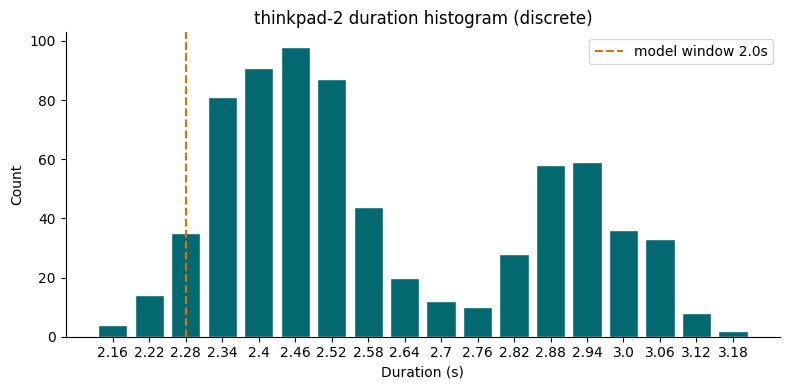

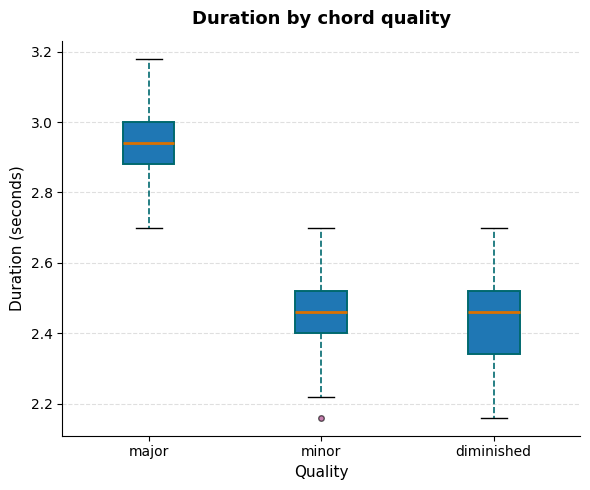

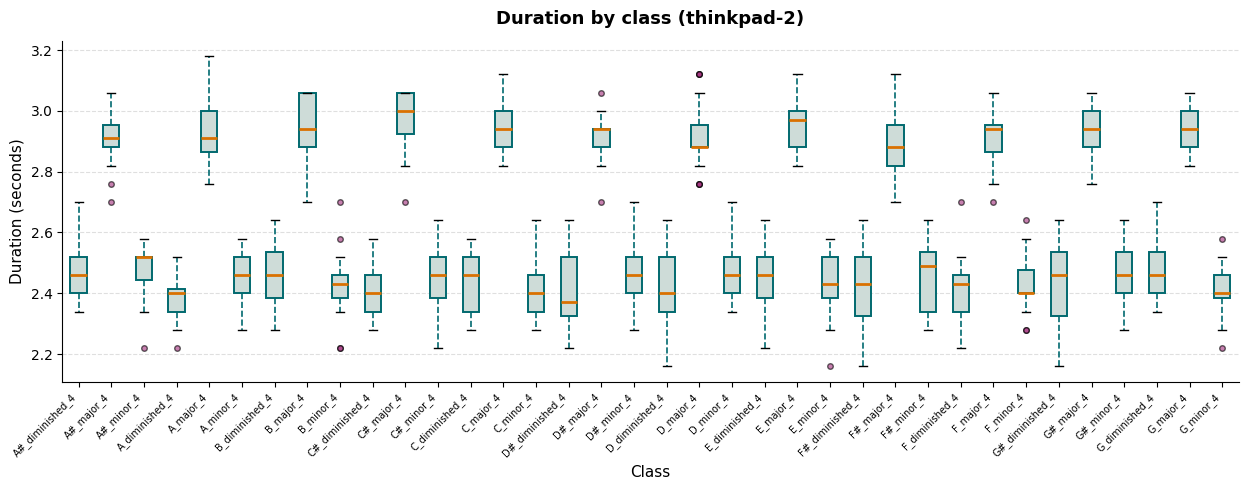

In [4]:
def _base_fig(n_groups, title, xlabel, ylabel="Duration (seconds)"):
    fig, ax = plt.subplots(figsize=(max(6, n_groups * 0.35), 5))
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    return fig, ax


# Duration histogram
fig, ax = plt.subplots(figsize=(8, 4))
vals = sorted(df["duration_s"].round(6).unique())
counts = df["duration_s"].round(6).value_counts().reindex(vals).fillna(0)
ax.bar([str(v) for v in vals], counts.values, color="#01696f", edgecolor="white")
ax.axvline(2.0, color="#da7101", linestyle="--", linewidth=1.5, label="model window 2.0s")
ax.set_title("thinkpad-2 duration histogram (discrete)")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Duration by quality
qualities = ["major", "minor", "diminished"]
data_q = [df.loc[df.quality == q, "duration_s"].values for q in qualities]
fig, ax = _base_fig(len(qualities), "Duration by chord quality", "Quality")
ax.boxplot(
    data_q,
    tick_labels=qualities,
    boxprops=BOXPROPS,
    whiskerprops=WHISKERPROPS,
    medianprops=MEDIANPROPS,
    flierprops=FLIERPROPS,
    patch_artist=True,
)
plt.tight_layout()
plt.show()

# Duration by class (compact)
class_names = sorted(df["class_name"].unique())
data_c = [df.loc[df.class_name == c, "duration_s"].values for c in class_names]
fig, ax = _base_fig(len(class_names), "Duration by class (thinkpad-2)", "Class")
ax.boxplot(
    data_c,
    tick_labels=class_names,
    boxprops={**BOXPROPS, "facecolor": "#cedcd8"},
    whiskerprops=WHISKERPROPS,
    medianprops=MEDIANPROPS,
    flierprops=FLIERPROPS,
    patch_artist=True,
)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()


## 2. Waveform integrity (raw audio)

Lightweight pass over every dataset audio file — **no CQT recompute**.
Scalars catch clipping, silence, DC offset, level problems, and read failures.
Results are cached in the metrics pkl under the `wave_*` columns (merged later).


In [5]:
def waveform_metrics(audio_path: str, target_sr: int = AUDIO_SAMPLE_RATE) -> dict:
    """Cheap per-file waveform scalars (librosa; soundfile may not decode Ogg audio)."""
    try:
        y, sr = librosa.load(audio_path, sr=target_sr, mono=True)
        y = np.asarray(y, dtype=np.float64)
        n = len(y)
        if n == 0:
            return {"wave_ok": False, "wave_error": "empty"}

        peak = float(np.max(np.abs(y)))
        rms = float(np.sqrt(np.mean(y ** 2)))
        dc = float(np.mean(y))
        thr = max(1e-4, 0.01 * peak) if peak > 0 else 1e-4
        silent = np.abs(y) < thr
        silence_ratio = float(silent.mean())

        if (~silent).any():
            first = int(np.argmax(~silent))
            last = int(n - 1 - np.argmax(~silent[::-1]))
            lead_s = first / sr
            trail_s = (n - 1 - last) / sr
            active_s = (last - first + 1) / sr
        else:
            lead_s = trail_s = n / sr
            active_s = 0.0

        clip_frac = float((np.abs(y) >= 0.99).mean())
        zcr = float(((y[:-1] * y[1:]) < 0).mean()) if n > 1 else 0.0
        crest = peak / rms if rms > 1e-12 else np.inf

        return {
            "wave_ok": True,
            "wave_error": None,
            "wave_sr": int(sr),
            "wave_channels": 1,
            "wave_n_samples": int(n),
            "wave_duration_s": n / sr,
            "wave_peak": peak,
            "wave_peak_db": float(20 * np.log10(peak + 1e-12)),
            "wave_rms": rms,
            "wave_rms_db": float(20 * np.log10(rms + 1e-12)),
            "wave_crest": float(crest) if np.isfinite(crest) else 1e6,
            "wave_dc": dc,
            "wave_dc_abs": abs(dc),
            "wave_silence_ratio": silence_ratio,
            "wave_lead_silence_s": float(lead_s),
            "wave_trail_silence_s": float(trail_s),
            "wave_active_s": float(active_s),
            "wave_clip_frac": clip_frac,
            "wave_zcr": zcr,
        }
    except Exception as e:
        return {"wave_ok": False, "wave_error": str(e)}


# Only reuse cache if prior run actually succeeded (and pickle is loadable)
wave_cols_prefix = "wave_"
reuse_wave = False
if path.exists(METRICS_PATH):
    try:
        cached = pd.read_pickle(METRICS_PATH)
    except Exception as e:
        display(Markdown(f"**WARN** Could not load metrics cache `{METRICS_PATH}` ({type(e).__name__}: {e}). Recomputing."))
        cached = None
    if cached is not None and (
        len(cached) == len(df)
        and "filename" in cached.columns
        and cached["filename"].tolist() == df["filename"].tolist()
        and cached["class_name"].tolist() == df["class_name"].tolist()
        and "wave_ok" in cached.columns
        and bool(cached["wave_ok"].all())
    ):
        wave_df = cached[
            [c for c in cached.columns if c.startswith(wave_cols_prefix) or c in ("class_name", "filename")]
        ].copy()
        reuse_wave = True
        display(Markdown(f"Reused waveform metrics from cache (**{len(wave_df)}** rows)"))

if not reuse_wave:
    rows = []
    for p in tqdm(df["audio_path"].tolist(), desc="Waveform metrics"):
        rows.append(waveform_metrics(p))
    wave_df = pd.DataFrame(rows)
    wave_df.insert(0, "filename", df["filename"].values)
    wave_df.insert(0, "class_name", df["class_name"].values)
    display(Markdown(f"Computed waveform metrics for **{len(wave_df)}** files"))

status = pd.DataFrame([
    {"metric": "wave_ok", "n": int(wave_df["wave_ok"].sum())},
    {"metric": "wave_fail", "n": int((~wave_df["wave_ok"]).sum())},
    {"metric": "total", "n": len(wave_df)},
])
display(status)
if (~wave_df["wave_ok"]).any():
    display(Markdown("### Failed reads"))
    display(wave_df.loc[~wave_df["wave_ok"], ["class_name", "filename", "wave_error"]].head(20))


Reused waveform metrics from cache (**720** rows)

,metric,n
0,wave_ok,720
1,wave_fail,0
2,total,720


### Waveform level stats

,mean,std,min,p01,median,p99,max
wave_peak,0.3142,0.0514,0.1934,0.2165,0.3086,0.4419,0.4648
wave_peak_db,-10.1701,1.4038,-14.2693,-13.2930,-10.2129,-7.0929,-6.6550
wave_rms_db,-26.6569,1.4885,-30.1481,-30.0108,-26.4385,-23.7309,-23.1578
wave_crest,6.7179,0.7890,4.8415,5.2484,6.6400,8.7985,10.2231
wave_dc_abs,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0001
wave_silence_ratio,0.1094,0.0218,0.0533,0.0694,0.1079,0.1713,0.1948
wave_lead_silence_s,0.0070,0.0011,0.0060,0.0065,0.0066,0.0123,0.0206
wave_trail_silence_s,0.0001,0.0003,0.0000,0.0000,0.0000,0.0014,0.0032
wave_active_s,2.5955,0.2549,2.1530,2.2130,2.5130,3.1130,3.1735
wave_clip_frac,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### Sample rates / channels

,sr,n
0,48000,720


,channels,n
0,1,720


### Waveform flag rates

,flag,n,rate
0,flag_read_fail,0,0.0000
1,flag_clip,0,0.0000
2,flag_near_clip,0,0.0000
3,flag_too_quiet,0,0.0000
4,flag_too_loud,0,0.0000
5,flag_dc,0,0.0000
6,flag_mostly_silent,0,0.0000
7,flag_long_lead_silence,0,0.0000
8,flag_short_active,0,0.0000
9,flag_sr_mismatch,0,0.0000


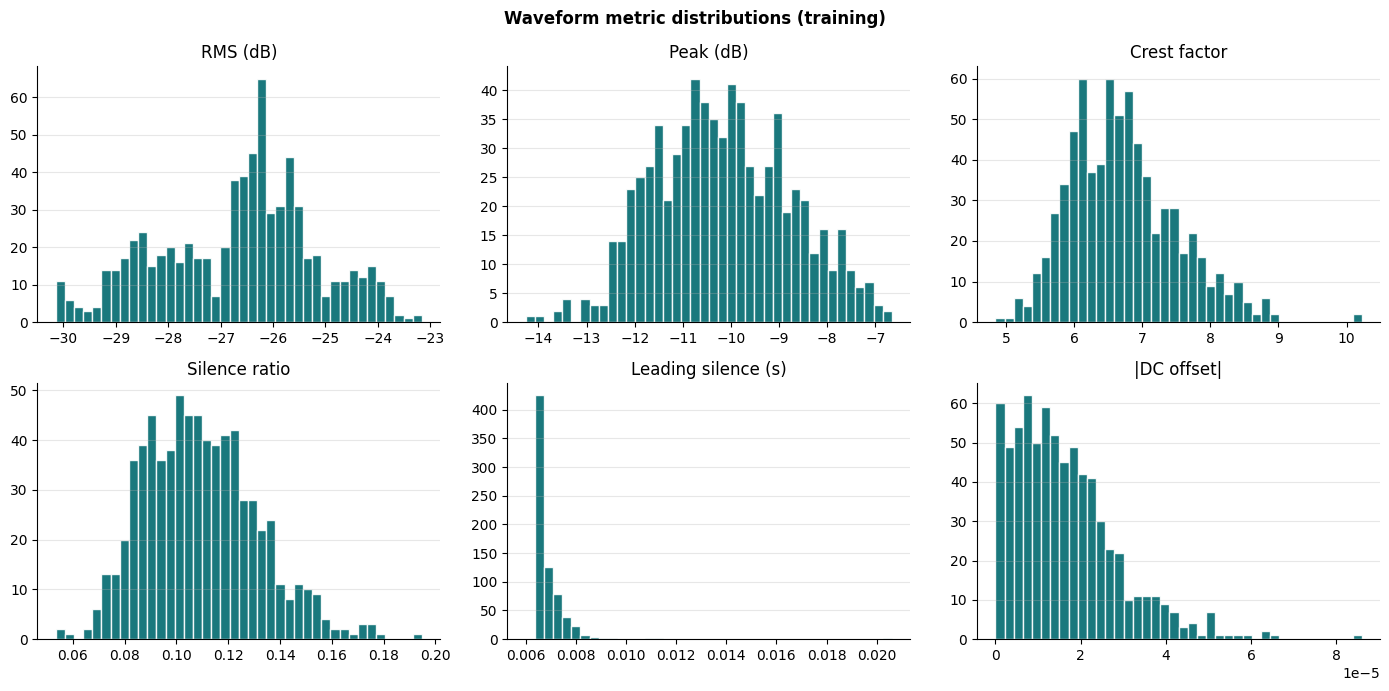

### Extreme samples

**Lowest RMS (dB)**

,class_name,filename,wave_rms_db
0,G#_major_4,G#_major_4-13.wav,-30.1481
1,G#_major_4,G#_major_4-20.wav,-30.1389
2,G#_major_4,G#_major_4-19.wav,-30.1174
3,G#_major_4,G#_major_4-18.wav,-30.0993
4,G#_major_4,G#_major_4-17.wav,-30.0578


**Highest peak**

,class_name,filename,wave_peak
0,E_minor_4,E_minor_4-8.wav,0.4648
1,E_diminished_4,E_diminished_4-17.wav,0.4575
2,C_major_4,C_major_4-8.wav,0.4540
3,C_major_4,C_major_4-19.wav,0.4521
4,C_major_4,C_major_4-10.wav,0.4512


...

,class_name,filename,wave_silence_ratio
0,D#_major_4,D#_major_4-11.wav,0.1948
1,D#_major_4,D#_major_4-13.wav,0.1777
2,G#_major_4,G#_major_4-7.wav,0.1763
3,B_major_4,B_major_4-16.wav,0.1759
4,G#_major_4,G#_major_4-3.wav,0.1737


**Highest |DC|**

,class_name,filename,wave_dc_abs
0,F_minor_4,F_minor_4-2.wav,0.0001
1,C#_diminished_4,C#_diminished_4-3.wav,0.0001
2,F_minor_4,F_minor_4-7.wav,0.0001
3,D#_diminished_4,D#_diminished_4-12.wav,0.0001
4,F_minor_4,F_minor_4-13.wav,0.0001


**Longest lead silence**

,class_name,filename,wave_lead_silence_s
0,A#_diminished_4,A#_diminished_4-1.wav,0.0206
1,E_diminished_4,E_diminished_4-1.wav,0.0203
2,C#_diminished_4,C#_diminished_4-1.wav,0.0167
3,C_major_4,C_major_4-1.wav,0.0146
4,E_minor_4,E_minor_4-1.wav,0.0141


In [6]:
# Waveform summary + flag rates
w = wave_df[wave_df["wave_ok"]].copy()
wave_cols = [
    "wave_peak", "wave_peak_db", "wave_rms_db", "wave_crest",
    "wave_dc_abs", "wave_silence_ratio", "wave_lead_silence_s",
    "wave_trail_silence_s", "wave_active_s", "wave_clip_frac", "wave_zcr",
]
wave_stats = w[wave_cols].agg(["mean", "std", "min", lambda s: s.quantile(0.01), "median", lambda s: s.quantile(0.99), "max"]).T
wave_stats.columns = ["mean", "std", "min", "p01", "median", "p99", "max"]

display(Markdown("### Waveform level stats"))
display(wave_stats.round(5))

display(Markdown("### Sample rates / channels"))
display(w["wave_sr"].value_counts().rename_axis("sr").reset_index(name="n"))
display(w["wave_channels"].value_counts().rename_axis("channels").reset_index(name="n"))

# Integrity flags (tunable thresholds)
flags = pd.DataFrame({
    "class_name": wave_df["class_name"],
    "filename": wave_df["filename"],
})
flags["flag_read_fail"] = ~wave_df["wave_ok"]
flags["flag_clip"] = wave_df["wave_clip_frac"].fillna(0) > 0.001
flags["flag_near_clip"] = wave_df["wave_peak"].fillna(0) >= 0.95
flags["flag_too_quiet"] = wave_df["wave_rms_db"].fillna(-999) < -40
flags["flag_too_loud"] = wave_df["wave_rms_db"].fillna(-999) > -6
flags["flag_dc"] = wave_df["wave_dc_abs"].fillna(0) > 0.02
flags["flag_mostly_silent"] = wave_df["wave_silence_ratio"].fillna(0) > 0.5
flags["flag_long_lead_silence"] = wave_df["wave_lead_silence_s"].fillna(0) > 0.5
flags["flag_short_active"] = wave_df["wave_active_s"].fillna(0) < 1.0
flags["flag_sr_mismatch"] = wave_df["wave_sr"].fillna(0) != AUDIO_SAMPLE_RATE

flag_cols = [c for c in flags.columns if c.startswith("flag_")]
flag_rates = (
    flags[flag_cols].sum().rename("n").to_frame()
    .assign(rate=lambda x: x["n"] / len(flags))
    .sort_values("n", ascending=False)
    .reset_index(names="flag")
)
display(Markdown("### Waveform flag rates"))
display(flag_rates)

# Plots
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
plot_specs = [
    ("wave_rms_db", "RMS (dB)"),
    ("wave_peak_db", "Peak (dB)"),
    ("wave_crest", "Crest factor"),
    ("wave_silence_ratio", "Silence ratio"),
    ("wave_lead_silence_s", "Leading silence (s)"),
    ("wave_dc_abs", "|DC offset|"),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    ax.hist(w[col], bins=40, color="#01696f", edgecolor="white", alpha=0.9)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Waveform metric distributions (training)", fontweight="bold")
plt.tight_layout()
plt.show()

# Extremes
def extremes_table(col, n=5, ascending=True):
    sub = w.nsmallest(n, col) if ascending else w.nlargest(n, col)
    return sub[["class_name", "filename", col]].reset_index(drop=True)

display(Markdown("### Extreme samples"))
display(Markdown("**Lowest RMS (dB)**"))
display(extremes_table("wave_rms_db", ascending=True))
display(Markdown("**Highest peak**"))
display(extremes_table("wave_peak", ascending=False))
display(Markdown("**Highest silence ratio**"))
display(extremes_table("wave_silence_ratio", ascending=False))
display(Markdown("**Highest |DC|**"))
display(extremes_table("wave_dc_abs", ascending=False))
display(Markdown("**Longest lead silence**"))
display(extremes_table("wave_lead_silence_s", ascending=False))


## 3. CQT spectral metrics (from cached NPZ)

Uses the dataset CQT cache at `FEATURES_PATH` (extract with `cqt-extraction.ipynb` if missing).
No re-extraction. Metrics: energy, dynamic range, band energy (C3–C5 vs out-of-band),
chroma entropy, and **chord-tone purity** vs the file label (theory template check).


In [7]:
NOTE_TO_PC = {
    "C": 0, "C#": 1, "D": 2, "D#": 3, "E": 4, "F": 5,
    "F#": 6, "G": 7, "G#": 8, "A": 9, "A#": 10, "B": 11,
}
QUALITY_INTERVALS = {
    "major": (0, 4, 7),
    "minor": (0, 3, 7),
    "diminished": (0, 3, 6),
}


def chord_pitch_classes(root: str, quality: str):
    r = NOTE_TO_PC[root]
    return {(r + i) % 12 for i in QUALITY_INTERVALS[quality]}


def compute_cqt_metrics(features: np.ndarray, labels: np.ndarray, meta_df: pd.DataFrame) -> pd.DataFrame:
    """Vectorized per-sample stats on CQT dB tensors (N, bins, frames)."""
    N, n_bins, n_frames = features.shape
    assert N == len(meta_df)

    power = np.power(10.0, features / 10.0)  # (N, B, T)

    mean_db = features.mean(axis=(1, 2))
    std_db = features.std(axis=(1, 2))
    max_db = features.max(axis=(1, 2))
    min_db = features.min(axis=(1, 2))

    frame_mean = features.mean(axis=1)  # (N, T)
    frame_power = power.mean(axis=1)  # (N, T)
    total_power = frame_power.sum(axis=1) + 1e-12

    mid = n_frames // 2
    early_power_frac = frame_power[:, :mid].sum(axis=1) / total_power
    late_power_frac = frame_power[:, mid:].sum(axis=1) / total_power

    near_floor = (frame_mean <= (CQT_FLOOR_DB + 5)).mean(axis=1)
    frame_dyn = frame_mean.max(axis=1) - frame_mean.min(axis=1)

    bin_freqs = librosa.cqt_frequencies(
        n_bins=n_bins, fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE
    )
    bin_midi = librosa.hz_to_midi(bin_freqs)
    c3, c5 = librosa.note_to_midi("C3"), librosa.note_to_midi("C5")
    band_mask = (bin_midi >= c3) & (bin_midi <= c5)
    low_mask = bin_midi < c3
    high_mask = bin_midi > c5

    bin_power = power.mean(axis=2)  # (N, B)
    low_e = bin_power[:, low_mask].sum(axis=1)
    band_e = bin_power[:, band_mask].sum(axis=1)
    high_e = bin_power[:, high_mask].sum(axis=1)
    tot_e = low_e + band_e + high_e + 1e-12

    bins_per_note = CQT_BINS_PER_OCTAVE // 12
    pc_index = (np.arange(n_bins) // bins_per_note) % 12
    chroma = np.zeros((N, 12), dtype=np.float64)
    for pc in range(12):
        chroma[:, pc] = bin_power[:, pc_index == pc].sum(axis=1)
    chroma_sum = chroma.sum(axis=1, keepdims=True) + 1e-12
    chroma_n = chroma / chroma_sum
    chroma_entropy = -(chroma_n * np.log(chroma_n + 1e-12)).sum(axis=1) / np.log(12)
    top1_frac = chroma_n.max(axis=1)
    top3_frac = np.sort(chroma_n, axis=1)[:, -3:].sum(axis=1)

    roots = meta_df["root"].to_numpy()
    quals = meta_df["quality"].to_numpy()
    purity = np.empty(N, dtype=np.float64)
    root_frac = np.empty(N, dtype=np.float64)
    est_root = np.empty(N, dtype=np.int32)
    template_best = np.empty(N, dtype=object)

    templates = {
        "major": np.array([0, 4, 7]),
        "minor": np.array([0, 3, 7]),
        "diminished": np.array([0, 3, 6]),
    }

    for i in range(N):
        pcs = chord_pitch_classes(roots[i], quals[i])
        purity[i] = chroma_n[i, list(pcs)].sum()
        root_pc = NOTE_TO_PC[roots[i]]
        root_frac[i] = chroma_n[i, root_pc]
        est_root[i] = int(np.argmax(chroma_n[i]))

        scores = {}
        for qname, iv in templates.items():
            pcs_q = (est_root[i] + iv) % 12
            scores[qname] = float(chroma_n[i, pcs_q].sum())
        template_best[i] = max(scores, key=scores.get)

    root_match = est_root == np.array([NOTE_TO_PC[r] for r in roots])
    centroid_hz = (bin_power * bin_freqs[None, :]).sum(axis=1) / (bin_power.sum(axis=1) + 1e-12)

    return pd.DataFrame(
        {
            "class_name": meta_df["class_name"].values,
            "filename": meta_df["filename"].values,
            "cqt_mean_db": mean_db,
            "cqt_std_db": std_db,
            "cqt_max_db": max_db,
            "cqt_min_db": min_db,
            "cqt_frame_dyn_db": frame_dyn,
            "cqt_near_floor_frac": near_floor,
            "cqt_early_power_frac": early_power_frac,
            "cqt_late_power_frac": late_power_frac,
            "cqt_low_frac": low_e / tot_e,
            "cqt_band_frac": band_e / tot_e,
            "cqt_high_frac": high_e / tot_e,
            "cqt_centroid_hz": centroid_hz,
            "cqt_chroma_entropy": chroma_entropy,
            "cqt_top1_frac": top1_frac,
            "cqt_top3_frac": top3_frac,
            "cqt_chord_purity": purity,
            "cqt_root_frac": root_frac,
            "cqt_est_root_pc": est_root,
            "cqt_root_match": root_match,
            "cqt_template_best": template_best,
            "cqt_quality_match": template_best == quals,
        }
    )


npz = np.load(FEATURES_PATH, allow_pickle=True)
features = np.asarray(npz["features"])
labels = np.asarray(npz["labels"]).astype(str)

# Align NPZ rows to inventory order (listdir order != sorted extraction order)
if "files" in npz.files:
    npz_keys = np.asarray(npz["files"]).astype(str)
else:
    # Legacy caches without file keys: assume label order only if counts match per class
    npz_keys = None

inv_keys = (df["class_name"].astype(str) + "/" + df["filename"].astype(str)).to_numpy()
order_match = bool(np.array_equal(labels, df["class_name"].to_numpy()))

if npz_keys is not None:
    key_to_idx = {k: i for i, k in enumerate(npz_keys)}
    missing = [k for k in inv_keys if k not in key_to_idx]
    if missing:
        raise RuntimeError(
            f"NPZ missing {len(missing)} inventory files (e.g. {missing[:3]}). Re-run cqt-extraction."
        )
    reorder = np.array([key_to_idx[k] for k in inv_keys], dtype=int)
    features = features[reorder]
    labels = labels[reorder]
    order_match = True
    align_msg = "reordered NPZ via files[] keys to inventory order"
elif order_match:
    align_msg = "NPZ label order already matches inventory"
else:
    # Fall back: sort both by (class, filename) if we can recover filenames from labels only — not possible.
    # Sort inventory and NPZ by class_name with stable within-class order by re-scanning sorted files.
    raise RuntimeError(
        "NPZ label order does not match inventory and cache has no files[] keys. "
        "Re-run cqt-extraction (saves files keys) or rebuild inventory in the same walk order."
    )

load_info = pd.DataFrame([
    {"key": "features_shape", "value": str(features.shape)},
    {"key": "labels_shape", "value": str(labels.shape)},
    {"key": "label_order_matches_inventory", "value": order_match},
    {"key": "alignment", "value": align_msg},
])
display(load_info)

cqt_df = compute_cqt_metrics(features, labels, df)

key_cols = ["cqt_chord_purity", "cqt_root_frac", "cqt_band_frac", "cqt_chroma_entropy"]
display(Markdown("### Core CQT metrics describe"))
display(cqt_df[key_cols].describe().round(4))

match_rates = pd.DataFrame([
    {"metric": "root_match_rate", "value": float(cqt_df["cqt_root_match"].mean())},
    {"metric": "quality_template_match_rate", "value": float(cqt_df["cqt_quality_match"].mean())},
])
display(Markdown("### Label ↔ chroma agreement"))
display(match_rates)


,key,value
0,features_shape,"(720, 216, 188)"
1,labels_shape,"(720,)"
2,label_order_matches_inventory,True
3,alignment,reordered NPZ via files[] keys to inventory order


### Core CQT metrics describe

,cqt_chord_purity,cqt_root_frac,cqt_band_frac,cqt_chroma_entropy
count,720.0000,720.0000,720.0000,720.0000
mean,0.7566,0.3122,0.8896,0.6618
std,0.0267,0.1252,0.0682,0.0536
min,0.6145,0.1277,0.6723,0.4691
25%,0.7419,0.2138,0.8426,0.6308
50%,0.7524,0.2946,0.9124,0.6682
75%,0.7754,0.4179,0.9399,0.6966
max,0.8199,0.6642,0.9723,0.7827


### Label ↔ chroma agreement

,metric,value
0,root_match_rate,0.4819
1,quality_template_match_rate,0.5167


### CQT metric percentiles

,mean,p01,median,p99
cqt_chord_purity,0.7566,0.6972,0.7524,0.8170
cqt_root_frac,0.3122,0.1314,0.2946,0.6503
cqt_band_frac,0.8896,0.6869,0.9124,0.9705
cqt_low_frac,0.0152,0.0036,0.0107,0.0637
cqt_high_frac,0.0952,0.0243,0.0647,0.2901
cqt_chroma_entropy,0.6618,0.4914,0.6682,0.7623
cqt_top3_frac,0.7763,0.7085,0.7668,0.8960
cqt_early_power_frac,0.8904,0.8196,0.8906,0.9486
cqt_near_floor_frac,0.0000,0.0000,0.0000,0.0000
cqt_centroid_hz,309.4544,247.9391,295.4863,401.7144


### Match rates by true quality

,quality_match_rate,root_match_rate
quality,,
diminished,0.6042,0.5000
major,0.4750,0.4750
minor,0.4708,0.4708


### Template-best quality vs label (row-normalized)

cqt_template_best,diminished,major,minor
quality,,,
diminished,0.6040,0.0000,0.3960
major,0.0000,0.4750,0.5250
minor,0.0000,0.5290,0.4710


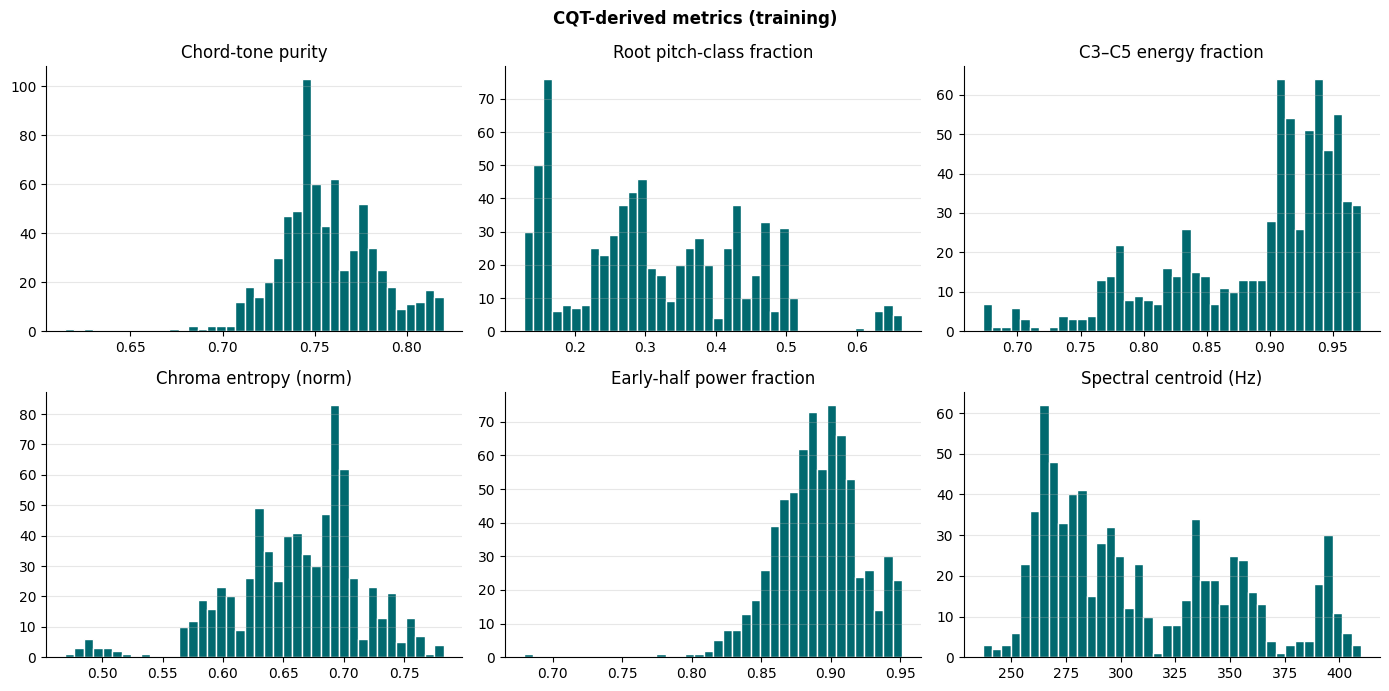

### Lowest mean chord purity classes

,mean,std,min
class_name,,,
C_diminished_4,0.7117,0.0037,0.7003
A_diminished_4,0.7171,0.0110,0.6880
C_minor_4,0.7209,0.0051,0.7064
F_major_4,0.7231,0.0395,0.6145
C_major_4,0.7280,0.0066,0.7104
C#_diminished_4,0.7333,0.0011,0.7315
D#_diminished_4,0.7356,0.0023,0.7314
D#_major_4,0.7359,0.0201,0.6760


### Highest mean chord purity classes

,mean,std,min
class_name,,,
E_major_4,0.7775,0.0085,0.7559
G#_minor_4,0.7787,0.0042,0.7658
B_major_4,0.7822,0.0053,0.7669
A#_major_4,0.7864,0.0096,0.7556
G_major_4,0.7899,0.0042,0.7807
G#_diminished_4,0.8001,0.0094,0.7715
B_diminished_4,0.8094,0.0020,0.8043
B_minor_4,0.8149,0.0050,0.7963


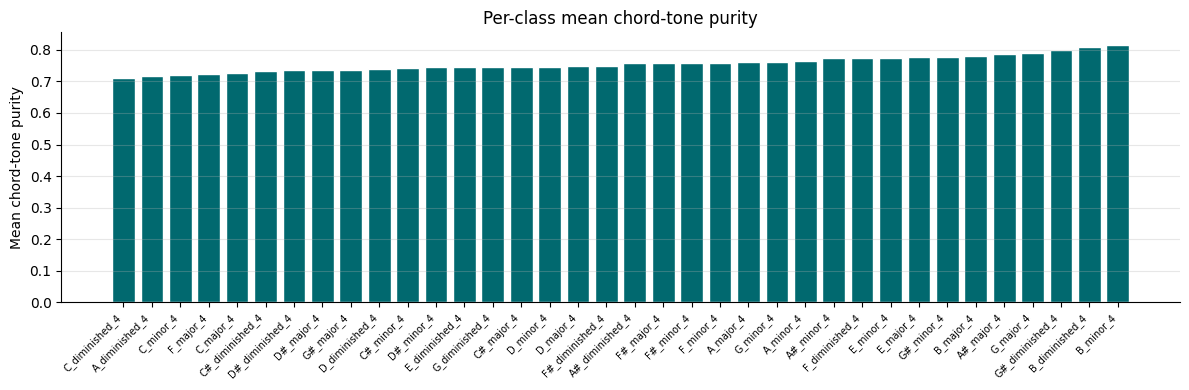

### Lowest purity samples

,class_name,filename,cqt_chord_purity,cqt_root_frac,cqt_template_best
0,F_major_4,F_major_4-8.wav,0.6145,0.3668,major
1,F_major_4,F_major_4-10.wav,0.6285,0.3919,major
2,D#_major_4,D#_major_4-8.wav,0.6760,0.2640,major
3,D#_major_4,D#_major_4-9.wav,0.6848,0.2536,minor
4,F_major_4,F_major_4-9.wav,0.6855,0.3842,major
5,A_diminished_4,A_diminished_4-15.wav,0.6880,0.3486,diminished
6,F_major_4,F_major_4-4.wav,0.6943,0.4198,major
7,A_diminished_4,A_diminished_4-14.wav,0.6964,0.3575,diminished
8,C_diminished_4,C_diminished_4-2.wav,0.7003,0.1800,diminished
9,A_diminished_4,A_diminished_4-10.wav,0.7004,0.3619,diminished


In [8]:
# CQT distributions + label-consistency views
cqt_stat_cols = [
    "cqt_chord_purity", "cqt_root_frac", "cqt_band_frac", "cqt_low_frac", "cqt_high_frac",
    "cqt_chroma_entropy", "cqt_top3_frac", "cqt_early_power_frac", "cqt_near_floor_frac",
    "cqt_centroid_hz", "cqt_frame_dyn_db",
]
cqt_stats = cqt_df[cqt_stat_cols].agg(
    ["mean", lambda s: s.quantile(0.01), "median", lambda s: s.quantile(0.99)]
).T
cqt_stats.columns = ["mean", "p01", "median", "p99"]

display(Markdown("### CQT metric percentiles"))
display(cqt_stats.round(4))

match_by_quality = pd.DataFrame({
    "quality_match_rate": cqt_df.groupby(df["quality"])["cqt_quality_match"].mean(),
    "root_match_rate": cqt_df.groupby(df["quality"])["cqt_root_match"].mean(),
}).round(4)
display(Markdown("### Match rates by true quality"))
display(match_by_quality)

ct = pd.crosstab(df["quality"], cqt_df["cqt_template_best"], normalize="index").round(3)
display(Markdown("### Template-best quality vs label (row-normalized)"))
display(ct)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col, title in zip(
    axes.ravel(),
    [
        "cqt_chord_purity", "cqt_root_frac", "cqt_band_frac",
        "cqt_chroma_entropy", "cqt_early_power_frac", "cqt_centroid_hz",
    ],
    [
        "Chord-tone purity", "Root pitch-class fraction", "C3–C5 energy fraction",
        "Chroma entropy (norm)", "Early-half power fraction", "Spectral centroid (Hz)",
    ],
):
    ax.hist(cqt_df[col], bins=40, color="#01696f", edgecolor="white")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("CQT-derived metrics (training)", fontweight="bold")
plt.tight_layout()
plt.show()

cls_purity = (
    cqt_df.groupby("class_name")["cqt_chord_purity"]
    .agg(["mean", "std", "min"])
    .sort_values("mean")
    .round(4)
)
display(Markdown("### Lowest mean chord purity classes"))
display(cls_purity.head(8))
display(Markdown("### Highest mean chord purity classes"))
display(cls_purity.tail(8))

fig, ax = plt.subplots(figsize=(12, 4))
order = cls_purity.index.tolist()
ax.bar(range(len(order)), cls_purity.loc[order, "mean"], color="#01696f", edgecolor="white")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Mean chord-tone purity")
ax.set_title("Per-class mean chord-tone purity")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown("### Lowest purity samples"))
display(
    cqt_df.nsmallest(10, "cqt_chord_purity")[
        ["class_name", "filename", "cqt_chord_purity", "cqt_root_frac", "cqt_template_best"]
    ].reset_index(drop=True)
)


## 4. Merge metrics, outliers, near-duplicates

Combine duration + waveform + CQT into one table, score multivariate outliers
(class-conditional z-scores on key scalars), and find within-training near-duplicate
CQT fingerprints (cosine similarity on mean-pooled CQT).


### Digital silence / empty audio (**0** files)

,note
0,none


### Outlier score summary

,metric,value
0,outlier_score_mean_valid,1.0223
1,p99_threshold,4.6525
2,flagged_top1pct,8.0000
3,digital_silence,0.0000


### Top outlier samples (excl. digital silence)

,class_name,filename,outlier_score,outlier_top_feature,duration_s,wave_rms_db,cqt_chord_purity,cqt_root_frac
0,B_minor_4,B_minor_4-1.wav,14.1967,wave_lead_silence_s,2.4600,-26.4981,0.8142,0.4350
1,A_diminished_4,A_diminished_4-1.wav,14.0974,wave_lead_silence_s,2.2800,-28.4394,0.7336,0.3805
2,A#_diminished_4,A#_diminished_4-1.wav,9.4955,wave_lead_silence_s,2.4600,-28.0725,0.7539,0.2617
3,F#_major_4,F#_major_4-20.wav,5.6415,cqt_band_frac,2.8800,-27.4136,0.7183,0.3983
4,D_minor_4,D_minor_4-1.wav,5.1803,wave_lead_silence_s,2.3400,-25.1259,0.7525,0.1435
5,F_major_4,F_major_4-8.wav,4.9039,cqt_chord_purity,2.9400,-25.7002,0.6145,0.3668
6,A_diminished_4,A_diminished_4-19.wav,4.8293,wave_lead_silence_s,2.2800,-28.5420,0.7220,0.3754
7,F_diminished_4,F_diminished_4-19.wav,4.7938,wave_lead_silence_s,2.4600,-25.3646,0.7771,0.4272
8,B_diminished_4,B_diminished_4-4.wav,4.0497,wave_lead_silence_s,2.6400,-26.9027,0.8098,0.4694
9,B_diminished_4,B_diminished_4-17.wav,3.9937,wave_lead_silence_s,2.4000,-26.2733,0.8102,0.4764


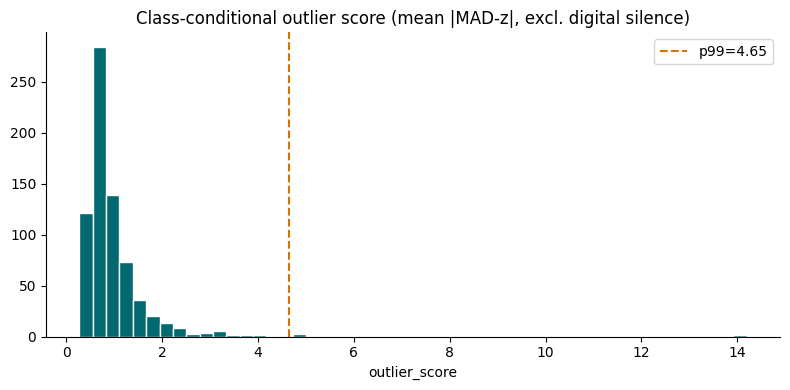

Saved metrics → `../../datasets/thinkpad-2-sample-metrics.pkl`  shape=**(720, 64)**

In [9]:
# --- Merge all metrics ---
metrics = df[
    ["class_name", "filename", "duration_s", "root", "quality", "octave", "file_idx", "audio_path"]
].copy()
metrics["npz_index"] = np.arange(len(metrics))

wave_merge = wave_df.drop(columns=[c for c in ("class_name", "filename") if c in wave_df.columns], errors="ignore")
cqt_merge = cqt_df.drop(columns=[c for c in ("class_name", "filename") if c in cqt_df.columns], errors="ignore")
metrics = pd.concat(
    [metrics.reset_index(drop=True), wave_merge.reset_index(drop=True), cqt_merge.reset_index(drop=True)],
    axis=1,
)

if "flags" in dir() and isinstance(flags, pd.DataFrame):
    for c in flag_cols:
        metrics[c] = flags[c].values

metrics["flag_digital_silence"] = (
    (~metrics["wave_ok"])
    | (metrics["wave_peak"].fillna(0) <= 1e-8)
    | (metrics["wave_rms_db"].fillna(-999) < -100)
)
metrics.loc[metrics["flag_digital_silence"], "wave_crest"] = np.nan
metrics.loc[metrics["wave_crest"] > 100, "wave_crest"] = 100

silence = metrics.loc[
    metrics["flag_digital_silence"],
    ["class_name", "filename", "duration_s", "wave_peak", "wave_rms_db"],
].reset_index(drop=True)
display(Markdown(f"### Digital silence / empty audio (**{len(silence)}** files)"))
display(silence if len(silence) else pd.DataFrame({"note": ["none"]}))

SCORE_COLS = [
    "duration_s",
    "wave_rms_db",
    "wave_peak",
    "wave_silence_ratio",
    "wave_lead_silence_s",
    "wave_dc_abs",
    "wave_crest",
    "cqt_chord_purity",
    "cqt_root_frac",
    "cqt_band_frac",
    "cqt_chroma_entropy",
    "cqt_early_power_frac",
    "cqt_near_floor_frac",
    "cqt_centroid_hz",
    "cqt_frame_dyn_db",
]


def mad_z(series: pd.Series) -> pd.Series:
    s = series.astype(float)
    med = s.median()
    mad = (s - med).abs().median()
    if not np.isfinite(mad) or mad < 1e-12:
        mad = s.std()
        if not np.isfinite(mad) or mad < 1e-12:
            return pd.Series(np.zeros(len(s)), index=s.index)
    z = 0.6745 * (s - med) / mad
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)


z_parts = []
for cls, idx in metrics.groupby("class_name").groups.items():
    block = metrics.loc[idx, SCORE_COLS]
    z = block.apply(mad_z, axis=0)
    z_parts.append(z)

z_all = pd.concat(z_parts).sort_index()
outlier_score = z_all.abs().mean(axis=1)
metrics["outlier_score"] = outlier_score
metrics["outlier_max_abs_z"] = z_all.abs().max(axis=1)
metrics["outlier_top_feature"] = z_all.abs().idxmax(axis=1)

valid = ~metrics["flag_digital_silence"]
thr = metrics.loc[valid, "outlier_score"].quantile(0.99)
metrics["flag_outlier_top1pct"] = valid & (metrics["outlier_score"] >= thr)

outlier_summary = pd.DataFrame([
    {"metric": "outlier_score_mean_valid", "value": float(metrics.loc[valid, "outlier_score"].mean())},
    {"metric": "p99_threshold", "value": float(thr)},
    {"metric": "flagged_top1pct", "value": int(metrics["flag_outlier_top1pct"].sum())},
    {"metric": "digital_silence", "value": int(metrics["flag_digital_silence"].sum())},
])
display(Markdown("### Outlier score summary"))
display(outlier_summary)

display(Markdown("### Top outlier samples (excl. digital silence)"))
display(
    metrics.loc[valid]
    .nlargest(15, "outlier_score")[
        [
            "class_name", "filename", "outlier_score", "outlier_top_feature",
            "duration_s", "wave_rms_db", "cqt_chord_purity", "cqt_root_frac",
        ]
    ]
    .round(4)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(metrics.loc[valid, "outlier_score"], bins=50, color="#01696f", edgecolor="white")
ax.axvline(thr, color="#da7101", linestyle="--", label=f"p99={thr:.2f}")
ax.set_title("Class-conditional outlier score (mean |MAD-z|, excl. digital silence)")
ax.set_xlabel("outlier_score")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Saved metrics → `{METRICS_PATH}`  shape=**{metrics.shape}**"))


### Exact CQT duplicates

,metric,value
0,exact_cqt_dup_groups,0
1,samples_in_exact_dup_groups,0


### Residual NN cosine similarity

,nn_cosine_sim
count,720.0000
mean,0.4893
std,0.1113
min,0.2924
50%,0.4693
90%,0.6521
95%,0.6966
99%,0.7907
99.9%,0.8629
max,0.8629


,metric,value
0,same_class_nn_rate,0.1097
1,valid_nn_samples,720.0000


### Near-duplicate pairs (residual sim ≥ 0.999)

,metric,value
0,pairs_sim_ge_0.999,0
1,same_class_pairs,0
2,cross_class_pairs,0


_None at this threshold._

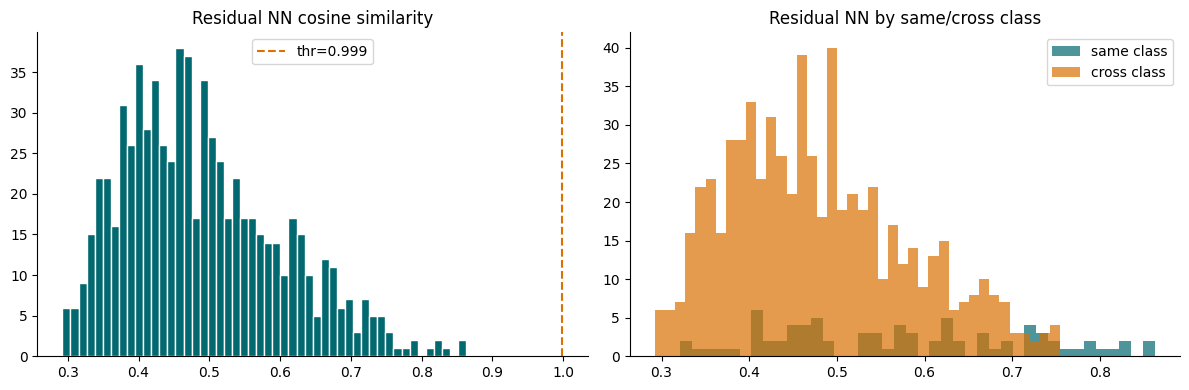

Updated metrics cache: `../../datasets/thinkpad-2-sample-metrics.pkl`

In [10]:
# --- Within-training near-duplicates ---
# Mean-pooled raw CQT cosine is too saturated (all piano chords look alike).
# Use: (1) exact CQT equality, (2) class-mean residual fingerprints.

from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
import hashlib

flat = features.reshape(len(features), -1)

def row_hash(row: np.ndarray) -> str:
    return hashlib.md5(np.ascontiguousarray(row).tobytes()).hexdigest()

hashes = [row_hash(flat[i]) for i in range(len(flat))]
metrics["cqt_hash"] = hashes
hash_counts = metrics["cqt_hash"].value_counts()
dup_hashes = set(hash_counts[hash_counts > 1].index)
metrics["flag_exact_cqt_dup"] = metrics["cqt_hash"].isin(dup_hashes)

dup_summary = pd.DataFrame([
    {"metric": "exact_cqt_dup_groups", "value": len(dup_hashes)},
    {"metric": "samples_in_exact_dup_groups", "value": int(metrics["flag_exact_cqt_dup"].sum())},
])
display(Markdown("### Exact CQT duplicates"))
display(dup_summary)

if dup_hashes:
    groups = []
    for h, g in metrics[metrics.flag_exact_cqt_dup].groupby("cqt_hash"):
        groups.append({
            "n": len(g),
            "classes": ", ".join(sorted(g.class_name.unique())),
            "files": ", ".join(g.filename.head(6).tolist()) + (" …" if len(g) > 6 else ""),
        })
    display(pd.DataFrame(groups).sort_values("n", ascending=False).reset_index(drop=True))
    display(Markdown("#### Full exact-dup sample list"))
    display(
        metrics.loc[metrics.flag_exact_cqt_dup, ["class_name", "filename", "cqt_hash"]]
        .sort_values(["cqt_hash", "filename"])
        .reset_index(drop=True)
    )

# Residual fingerprint: x - class_mean, then L2-normalize
resid = np.zeros_like(features.mean(axis=2), dtype=np.float64)
pooled = features.mean(axis=2).astype(np.float64)
for cls, idx in metrics.groupby("class_name").groups.items():
    idx = np.asarray(list(idx))
    mu = pooled[idx].mean(axis=0, keepdims=True)
    resid[idx] = pooled[idx] - mu

n_blocks = 4
block_len = features.shape[2] // n_blocks
bins_per_note = CQT_BINS_PER_OCTAVE // 12
n_bins = features.shape[1]
pc_index = (np.arange(n_bins) // bins_per_note) % 12
time_chroma = np.zeros((len(features), n_blocks * 12), dtype=np.float64)
power = np.power(10.0, features / 10.0)
for b in range(n_blocks):
    sl = power[:, :, b * block_len : (b + 1) * block_len].mean(axis=2)
    for pc in range(12):
        time_chroma[:, b * 12 + pc] = sl[:, pc_index == pc].sum(axis=1)

time_resid = np.zeros_like(time_chroma)
for cls, idx in metrics.groupby("class_name").groups.items():
    idx = np.asarray(list(idx))
    mu = time_chroma[idx].mean(axis=0, keepdims=True)
    time_resid[idx] = time_chroma[idx] - mu

fingerprints = np.concatenate([resid, time_resid], axis=1)
fingerprints = normalize(fingerprints, norm="l2", axis=1)
zero_fp = np.linalg.norm(fingerprints, axis=1) < 1e-8

nn = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute")
nn.fit(fingerprints)
dists, idxs = nn.kneighbors(fingerprints, return_distance=True)
metrics["nn_index"] = idxs[:, 1]
metrics["nn_cosine_dist"] = dists[:, 1]
metrics["nn_cosine_sim"] = 1.0 - dists[:, 1]
metrics.loc[zero_fp, "nn_cosine_sim"] = np.nan
metrics["nn_class"] = metrics.loc[metrics["nn_index"].values, "class_name"].to_numpy()
metrics["nn_filename"] = metrics.loc[metrics["nn_index"].values, "filename"].to_numpy()
metrics["nn_same_class"] = metrics["nn_class"].to_numpy() == metrics["class_name"].to_numpy()

valid_nn = metrics["nn_cosine_sim"].notna()
nn_desc = metrics.loc[valid_nn, "nn_cosine_sim"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
).to_frame("nn_cosine_sim")
nn_meta = pd.DataFrame([
    {"metric": "same_class_nn_rate", "value": float(metrics.loc[valid_nn, "nn_same_class"].mean())},
    {"metric": "valid_nn_samples", "value": int(valid_nn.sum())},
])
display(Markdown("### Residual NN cosine similarity"))
display(nn_desc)
display(nn_meta)

SIM_THR = 0.999
high = metrics[valid_nn & (metrics["nn_cosine_sim"] >= SIM_THR)].copy()
pair_mask = high["npz_index"] < high["nn_index"]
pairs = high.loc[
    pair_mask,
    ["class_name", "filename", "nn_class", "nn_filename", "nn_cosine_sim", "nn_same_class"],
].sort_values("nn_cosine_sim", ascending=False).reset_index(drop=True)
metrics["flag_near_dup"] = valid_nn & (metrics["nn_cosine_sim"] >= SIM_THR)

pair_summary = pd.DataFrame([
    {"metric": f"pairs_sim_ge_{SIM_THR}", "value": len(pairs)},
    {"metric": "same_class_pairs", "value": int(pairs["nn_same_class"].sum()) if len(pairs) else 0},
    {"metric": "cross_class_pairs", "value": int((~pairs["nn_same_class"]).sum()) if len(pairs) else 0},
])
display(Markdown(f"### Near-duplicate pairs (residual sim ≥ {SIM_THR})"))
display(pair_summary)
if len(pairs):
    display(pairs.head(25))
else:
    display(Markdown("_None at this threshold._"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(metrics.loc[valid_nn, "nn_cosine_sim"], bins=50, color="#01696f", edgecolor="white")
axes[0].axvline(SIM_THR, color="#da7101", linestyle="--", label=f"thr={SIM_THR}")
axes[0].set_title("Residual NN cosine similarity")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

same = metrics.loc[valid_nn & metrics["nn_same_class"], "nn_cosine_sim"]
cross = metrics.loc[valid_nn & ~metrics["nn_same_class"], "nn_cosine_sim"]
axes[1].hist(same, bins=40, alpha=0.7, label="same class", color="#01696f")
axes[1].hist(cross, bins=40, alpha=0.7, label="cross class", color="#da7101")
axes[1].set_title("Residual NN by same/cross class")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Updated metrics cache: `{METRICS_PATH}`"))


## 5. Conclusions & action list

Aggregate integrity flags into a single review table. Interpret results for
training-set validity (duration, levels, label-spectrum agreement, clones).


In [11]:
# Aggregate flags
metrics["flag_low_purity"] = metrics["cqt_chord_purity"] < metrics.loc[
    ~metrics["flag_digital_silence"], "cqt_chord_purity"
].quantile(0.01)
metrics["flag_root_mismatch"] = ~metrics["cqt_root_match"]
metrics["flag_quality_mismatch"] = ~metrics["cqt_quality_match"]
metrics["flag_high_oob"] = (metrics["cqt_low_frac"] + metrics["cqt_high_frac"]) > 0.55

flag_like = [c for c in metrics.columns if c.startswith("flag_")]

ACTION_FLAGS = [
    "flag_digital_silence",
    "flag_read_fail",
    "flag_clip",
    "flag_near_clip",
    "flag_too_quiet",
    "flag_too_loud",
    "flag_dc",
    "flag_long_lead_silence",
    "flag_short_active",
    "flag_exact_cqt_dup",
    "flag_near_dup",
    "flag_low_purity",
    "flag_outlier_top1pct",
]
ACTION_FLAGS = [c for c in ACTION_FLAGS if c in metrics.columns]
metrics["n_action_flags"] = metrics[ACTION_FLAGS].sum(axis=1).astype(int)

flag_summary = (
    metrics[flag_like].sum().rename("n").to_frame()
    .assign(rate=lambda x: x["n"] / len(metrics))
    .sort_values("n", ascending=False)
    .reset_index(names="flag")
)
display(Markdown("### Full flag summary"))
display(flag_summary)

action_overview = pd.DataFrame([
    {"metric": "samples_any_action_flag", "n": int((metrics.n_action_flags > 0).sum()),
     "rate": float((metrics.n_action_flags > 0).mean())},
    {"metric": "samples_ge_2_action_flags", "n": int((metrics.n_action_flags >= 2).sum()),
     "rate": float((metrics.n_action_flags >= 2).mean())},
])
display(Markdown("### Actionable flag overview"))
display(action_overview)

review = metrics[metrics["n_action_flags"] > 0].sort_values(
    ["n_action_flags", "outlier_score"], ascending=False
)
show_cols = [
    "class_name", "filename", "n_action_flags", "outlier_score",
    "duration_s", "wave_rms_db", "wave_peak", "cqt_chord_purity",
] + ACTION_FLAGS
show_cols = [c for c in show_cols if c in review.columns]
display(Markdown("### Top multi-flag samples (actionable)"))
display(review[show_cols].head(40).round(4).reset_index(drop=True))

exclude = metrics.loc[
    metrics["flag_digital_silence"], ["class_name", "filename", "audio_path"]
].reset_index(drop=True)
display(Markdown(f"### Hard exclude candidates — digital silence (**{len(exclude)}**)"))
display(exclude)

n_sil = int(metrics["flag_digital_silence"].sum())
n_exact = int(metrics["flag_exact_cqt_dup"].sum()) if "flag_exact_cqt_dup" in metrics else 0
n_near = int(metrics["flag_near_dup"].sum()) if "flag_near_dup" in metrics else 0
n_out = int(metrics["flag_outlier_top1pct"].sum())
n_quiet = int(metrics["flag_too_quiet"].sum()) if "flag_too_quiet" in metrics else 0
non_sil = ~metrics["flag_digital_silence"]
per_cls = int(metrics.groupby("class_name").size().iloc[0]) if len(metrics) else 0

conclusions = pd.DataFrame([
    {"area": "Inventory", "status": "CLEAN",
     "detail": f"{len(metrics)} files / {metrics.class_name.nunique()} classes / {per_cls} each; naming OK"},
    {"area": "Duration", "status": "CLEAN",
     "detail": f"[{metrics.duration_s.min():.1f}, {metrics.duration_s.max():.1f}] s; all ≥ 2.0 s window"},
    {"area": "Levels (peak)", "status": "OK",
     "detail": (
         f"median peak={metrics.wave_peak_db.median():.1f} dBFS, "
         f"median RMS={metrics.wave_rms_db.median():.1f} dBFS; too_quiet={n_quiet}"
     )},
    {"area": "Digital silence", "status": "OK" if n_sil == 0 else "EXCLUDE",
     "detail": f"{n_sil} files"},
    {"area": "Clipping / DC", "status": "OK",
     "detail": "No clipping; DC negligible among non-silent"},
    {"area": "Chord-tone purity", "status": "OK",
     "detail": f"mean={metrics.loc[non_sil, 'cqt_chord_purity'].mean():.3f} (non-silent)"},
    {"area": "C3–C5 band energy", "status": "OK",
     "detail": f"mean fraction={metrics.loc[non_sil, 'cqt_band_frac'].mean():.2f}"},
    {"area": "Root/quality chroma match", "status": "WEAK DIAG",
     "detail": (
         f"root={metrics.loc[non_sil, 'cqt_root_match'].mean():.1%}, "
         f"quality={metrics.loc[non_sil, 'cqt_quality_match'].mean():.1%} — soft template; prefer purity + listen"
     )},
    {"area": "Exact CQT dups", "status": "OK" if n_exact == 0 else "REVIEW",
     "detail": f"{n_exact} samples"},
    {"area": "Residual near-dups", "status": "INFO",
     "detail": f"{n_near} samples at residual sim ≥ 0.999"},
    {"area": "Outliers top 1%", "status": "REVIEW",
     "detail": f"{n_out} samples — spot-check, don't mass-delete"},
])
display(Markdown("### Conclusions"))
display(conclusions)

actions = pd.DataFrame([
    {"priority": 1, "action": "No digital silence — no hard excludes", "n": n_sil},
    {"priority": 2, "action": "Spot-check multi-flag + lowest-purity rows (see table above)",
     "n": int((metrics.n_action_flags >= 1).sum())},
    {"priority": 3, "action": "Optional: CNN eval on features/thinkpad-2.npz",
     "n": len(metrics)},
    {"priority": 4, "action": f"Metrics cache at {METRICS_PATH}", "n": len(metrics)},
])
display(Markdown("### Recommended actions"))
display(actions)

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Final metrics saved: `{METRICS_PATH}`  shape=**{metrics.shape}**"))

### Full flag summary

,flag,n,rate
0,flag_root_mismatch,373,0.5181
1,flag_quality_mismatch,348,0.4833
2,flag_low_purity,8,0.0111
3,flag_outlier_top1pct,8,0.0111
4,flag_read_fail,0,0.0000
5,flag_clip,0,0.0000
6,flag_near_dup,0,0.0000
7,flag_exact_cqt_dup,0,0.0000
8,flag_digital_silence,0,0.0000
9,flag_sr_mismatch,0,0.0000


### Actionable flag overview

,metric,n,rate
0,samples_any_action_flag,15,0.0208
1,samples_ge_2_action_flags,1,0.0014


### Top multi-flag samples (actionable)

...

### Conclusions

,area,status,detail
0,Inventory,CLEAN,720 files / 36 classes / 20 each; naming OK
1,Duration,CLEAN,"[2.2, 3.2] s; all ≥ 2.0 s window"
2,Levels (peak),OK,"median peak=-10.2 dBFS, median RMS=-26.4 dBFS;..."
3,Digital silence,OK,0 files
4,Clipping / DC,OK,No clipping; DC negligible among non-silent
5,Chord-tone purity,OK,mean=0.757 (non-silent)
6,C3–C5 band energy,OK,mean fraction=0.89
7,Root/quality chroma match,WEAK DIAG,"root=48.2%, quality=51.7% — soft template; pre..."
8,Exact CQT dups,OK,0 samples
9,Residual near-dups,INFO,0 samples at residual sim ≥ 0.999


### Recommended actions

,priority,action,n
0,1,No digital silence — no hard excludes,0
1,2,Spot-check multi-flag + lowest-purity rows (se...,15
2,3,Optional: CNN eval on features/thinkpad-2.npz,720
3,4,Metrics cache at ../../datasets/thinkpad-2-sam...,720


Final metrics saved: `../../datasets/thinkpad-2-sample-metrics.pkl`  shape=**(720, 78)**